In [132]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
from LSTM_model_train import AssistLSTM
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from data_proc_2d.app.build_norm_dataset import NormDatasetBuilder


In [133]:
import gc
import hashlib
import json
import shutil
import tempfile
import zipfile


def cached_npz_arrays(npz_path, keys, cache_dir):
    """Stream selected .npy members to local disk, then open read-only mappings."""
    npz_path = Path(npz_path).resolve()
    stat = npz_path.stat()
    signature = json.dumps([str(npz_path), stat.st_size, stat.st_mtime_ns, keys])
    cache_key = hashlib.sha256(signature.encode()).hexdigest()
    directory = Path(cache_dir) / cache_key
    paths = [directory / f"{i}.npy" for i in range(len(keys))]
    if not all(path.exists() for path in paths):
        directory.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(npz_path) as archive:
            for key, path in zip(keys, paths):
                if path.exists():
                    continue
                # Publish only complete files; an interrupted copy can be retried.
                with tempfile.NamedTemporaryFile(dir=directory, suffix=".tmp", delete=False) as target:
                    temporary = Path(target.name)
                    try:
                        with archive.open(f"{key}.npy") as member:
                            shutil.copyfileobj(member, target, length=1024 * 1024)
                    except BaseException:
                        target.close()
                        temporary.unlink(missing_ok=True)
                        raise
                try:
                    temporary.replace(path)
                finally:
                    temporary.unlink(missing_ok=True)
    return [np.load(path, mmap_mode="r", allow_pickle=False) for path in paths]


class AssistSequenceDataset(Dataset):
    def __init__(
        self,
        npz_path,
        window_size=120,
        stride=30,
        predict_offset=0,
        mode="seq2seq",   # "seq2one" or "seq2seq"
        feature_keys=None, # choose features here
        cache_dir=None,
    ):
        super().__init__()

        if window_size <= 0 or stride <= 0 or predict_offset < 0:
            raise ValueError("window_size and stride must be positive; predict_offset must be nonnegative")
        if mode not in ("seq2one", "seq2seq"):
            raise ValueError("mode must be seq2one or seq2seq")
        self.feature_keys = ["ratios"] if feature_keys is None else list(feature_keys)
        if not self.feature_keys:
            raise ValueError("feature_keys must not be empty")
        cache_dir = ROOT / "model_lstm" / ".dataset_cache" if cache_dir is None else Path(cache_dir)
        arrays = cached_npz_arrays(
            npz_path, self.feature_keys + ["task_id", "task_progress", "mistake"], cache_dir
        )
        self.features = arrays[:-3]
        self.step, self.progress, self.mistake = arrays[-3:]

        # ===== config =====
        self.window_size = window_size
        self.stride = stride
        self.predict_offset = predict_offset
        self.mode = mode

        if any(feature.ndim != 2 for feature in self.features):
            raise ValueError("Features must have shape (frames, dimensions)")
        self.T = self.features[0].shape[0]
        if any(feature.shape[0] != self.T for feature in self.features):
            raise ValueError("All features must have the same number of frames")
        if any(label.shape != (self.T,) for label in (self.step, self.progress, self.mistake)):
            raise ValueError("Labels must have shape (frames,) matching the features")

        # A range stores the sliding-window indices without a list per window.
        self.indices = range(0, max(0, self.T - window_size - predict_offset + 1), stride)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        start = self.indices[idx]
        end = start + self.window_size
        target_index = end - 1 + self.predict_offset

        # Allocate only this window; modifying x cannot change the disk cache.
        x = torch.from_numpy(np.concatenate(
            [feature[start:end] for feature in self.features],
            axis=1, dtype=np.float32, casting="unsafe",
        ))

        # =====================================================
        # build Y
        # =====================================================
        if self.mode == "seq2one":
            y = {
                "step": torch.tensor(self.step[target_index], dtype=torch.long),
                "progress": torch.tensor(self.progress[target_index], dtype=torch.float32),
                "mistake": torch.tensor(self.mistake[target_index], dtype=torch.long),
            }
        elif self.mode == "seq2seq":
            y = {
                "step": torch.tensor(self.step[start:end], dtype=torch.long),
                "progress": torch.tensor(self.progress[start:end], dtype=torch.float32),
                "mistake": torch.tensor(self.mistake[start:end], dtype=torch.long),
            }
        else:
            raise ValueError("mode must be seq2one or seq2seq")

        return x, y


def window_class_counts(datasets):
    """Count seq2one targets in bounded chunks, without collecting all labels."""
    counts = np.zeros(0, dtype=np.int64)
    for dataset in datasets:
        if dataset.mode != "seq2one":
            raise ValueError("Window label statistics require seq2one mode.")
        first = dataset.window_size - 1 + dataset.predict_offset
        chunk_frames = dataset.stride * 65536
        for start in range(first, dataset.T, chunk_frames):
            targets = dataset.step[start:min(start + chunk_frames, dataset.T):dataset.stride]
            current = np.bincount(targets.astype(np.int64, copy=False))
            if len(current) > len(counts):
                counts = np.pad(counts, (0, len(current) - len(counts)))
            counts[:len(current)] += current
    return counts


def balanced_window_sampler(datasets, seed=42):
    """Balance seq2one target classes across all files, without reading features."""
    counts = window_class_counts(datasets)
    num_windows = sum(len(dataset) for dataset in datasets)
    if num_windows == 0:
        raise ValueError("Balanced sampling requires at least one training window")
    weights = np.empty(num_windows, dtype=np.float64)
    offset = 0
    for dataset in datasets:
        first = dataset.window_size - 1 + dataset.predict_offset
        chunk_frames = dataset.stride * 65536
        for start in range(first, dataset.T, chunk_frames):
            targets = dataset.step[start:min(start + chunk_frames, dataset.T):dataset.stride]
            targets = targets.astype(np.int64, copy=False)
            weights[offset:offset + len(targets)] = 1.0 / np.sqrt(counts[targets])  
            offset += len(targets)
    sampler = WeightedRandomSampler(
        torch.from_numpy(weights), num_samples=num_windows, replacement=True,
        generator=torch.Generator().manual_seed(seed),
    )
    return sampler, counts


def release_notebook_data(*names):
    """Drop all notebook references before rebuilding or switching datasets."""
    for name in names:
        globals().pop(name, None)
    gc.collect()


In [ ]:
test_notes = "Mirrored Augmentation Test with no weighted ce and sqrt balanced sampler and weighted ce 1**"

In [135]:
#device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### hyper param short epoch test

In [ ]:
# #training config
# epochs = 60
# batch_size = 32
# lr = 3e-4

# #sliding window config
# window_size = 160
# stride = 30
# predict_offset = 0
# num_workers = 4

# mode = "seq2one"  # "seq2one" or "seq2seq"

# hidden_layer = 64

# train_shuffle = False


### hyper param optimization

In [136]:
#training config
epochs = 60
batch_size = 32
lr = 1e-4

#sliding window config
window_size = 160
stride = 30
predict_offset = 0
# This notebook defines its Dataset locally. Keep 0 for Windows/Jupyter.
num_workers = 0
# Local uncompressed cache: first use streams from NPZ; later runs reuse it.
dataset_cache_dir = ROOT / "model_lstm" / ".dataset_cache"

mode = "seq2one"  # "seq2one" or "seq2seq"

hidden_layer = 64

# The weighted sampler supplies randomness; DataLoader shuffle must stay False.
train_shuffle = False
sampler_seed = 42

dropout = 0.2
num_layers = 1

weighted_loss = True

weight_decay = 0.01

## load training data

In [137]:
npz_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_train\norm"
npz_paths = [os.path.join(npz_dir, f) for f in os.listdir(npz_dir) if f.endswith(".npz")]
datasets = []
print(len(npz_paths))

225


## load norm.npz

In [138]:
# Materialize the small statistics once, then close the archive.
with np.load(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data_proc_3d\dataset\norm_mirrored_2026-09-24.npz", allow_pickle=True) as stats_file:
    norm_stats = {key: stats_file[key] for key in stats_file.files}


## load & norm val data

In [139]:
val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\raw"
val_paths = [os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith(".pt")]

npz_val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\norm"

In [140]:
# Reuse cached files; use a new directory if normalization statistics change.
Path(npz_val_dir).mkdir(parents=True, exist_ok=True)
builder = NormDatasetBuilder(norm_stats)
for val_path in val_paths:
    out_path = Path(npz_val_dir) / (Path(val_path).stem + "_norm.npz")
    if not out_path.exists():
        builder.build_dataset(val_path, str(out_path))


In [141]:

npz_val_paths = [os.path.join(npz_val_dir, f) for f in os.listdir(npz_val_dir) if f.endswith(".npz")]
print(len(npz_val_paths))

27


In [142]:
FEATURE_KEYS = [
    'joint_speed', 
    'joint_acceleration', 
    'joint_velocity_x', 
    'joint_velocity_y', 
    'joint_velocity_z', 
    'joint_acceleration_x', 
    'joint_acceleration_y', 
    'joint_acceleration_z', 
    'position_x_relative_to_pelvis', 
    'position_y_relative_to_pelvis', 
    'position_z_relative_to_pelvis', 
    'polar_azimuth', 
    'polar_elevation', 
    'joint_angles', 
    'ratios', 
    'distance_from_center'
]

# Change the selected features here!!

In [143]:
x_keys = [
         'distance_from_center',
         'position_x_relative_to_pelvis', 
         'position_y_relative_to_pelvis', 
         'position_z_relative_to_pelvis', 
         'joint_angles', 
         'polar_elevation'
        ]

## training dataset

In [168]:
release_notebook_data("loader", "train_eval_loader", "train_sampler", "full_dataset", "datasets", "dataset",
                      "x_sample", "y_sample", "train_targets")
datasets = []
for npz_path in npz_paths:
    print(f"Loading dataset from {npz_path}...")
    dataset = AssistSequenceDataset(npz_path=npz_path,
                                    window_size=window_size,
                                    stride=stride,
                                    predict_offset=predict_offset,
                                    mode= mode,
                                    feature_keys=x_keys,
                                    cache_dir=dataset_cache_dir)
    datasets.append(dataset)
    
full_dataset = ConcatDataset(datasets)

train_sampler, train_class_counts = balanced_window_sampler(datasets, seed=sampler_seed)
loader = DataLoader(full_dataset, batch_size=batch_size, sampler=train_sampler, shuffle=train_shuffle, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
# Evaluate each original training window exactly once, without resampling.
train_eval_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
# Shape checks below access a single sample without starting a loader iterator.
print("Training windows:", len(full_dataset))
print("Training sampler: inverse class frequency, replacement=True, windows/epoch:", len(train_sampler))
print("Expected sampled class proportions:", {
    int(label): round(1.0 / np.count_nonzero(train_class_counts), 4)
    for label in np.flatnonzero(train_class_counts)
})
print("Feature data mapped from disk (GiB):", round(sum(f.nbytes for d in datasets for f in d.features) / 2**30, 3))
print("Dataset cache:", dataset_cache_dir)


Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_train\norm\features__cam-05_uid-14_take-01_aug-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_train\norm\features__cam-05_uid-14_take-01_aug-02_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_train\norm\features__cam-05_uid-14_take-01_aug-03_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_train\norm\features__cam-05_uid-14_take-02_aug-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceilin

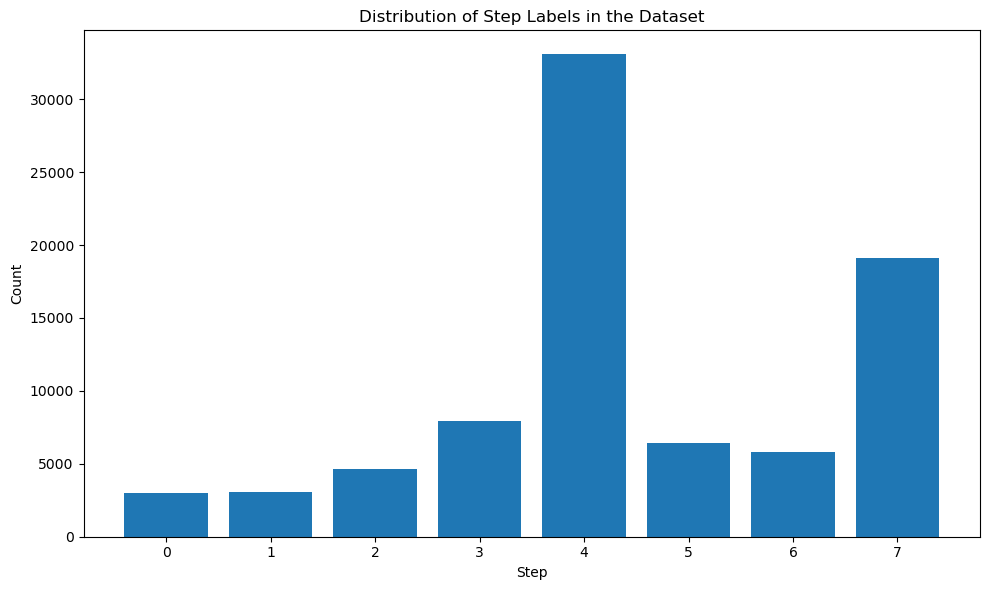

{0: 2994, 1: 3096, 2: 4611, 3: 7947, 4: 33072, 5: 6405, 6: 5844, 7: 19107}


In [145]:
# Original window distribution; training batches use balanced sampling.
counts = {label: int(count) for label, count in enumerate(train_class_counts) if count}

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

## val dataset

In [166]:
release_notebook_data("val_loader", "fulldataset_val", "val_datasets", "val_dataset",
                      "x_val_sample", "y_val_sample", "val_targets")
val_datasets = []
for npz_val_path in npz_val_paths:
    print(f"Loading validation dataset from {npz_val_path}...")
    val_dataset = AssistSequenceDataset(npz_path=npz_val_path,
                                        window_size=window_size,
                                        stride=stride,
                                        predict_offset=predict_offset,
                                        mode=mode,
                                        feature_keys=x_keys,
                                        cache_dir=dataset_cache_dir)
    val_datasets.append(val_dataset)    

fulldataset_val = ConcatDataset(val_datasets)

val_loader = DataLoader(fulldataset_val, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\norm\features__cam-06_uid-15_take-02_aug-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\norm\features__cam-07_uid-15_take-02_aug-03_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\norm\features__cam-07_uid-15_take-02_aug-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_val\norm\features__cam-07_uid-15_take-02_aug-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC

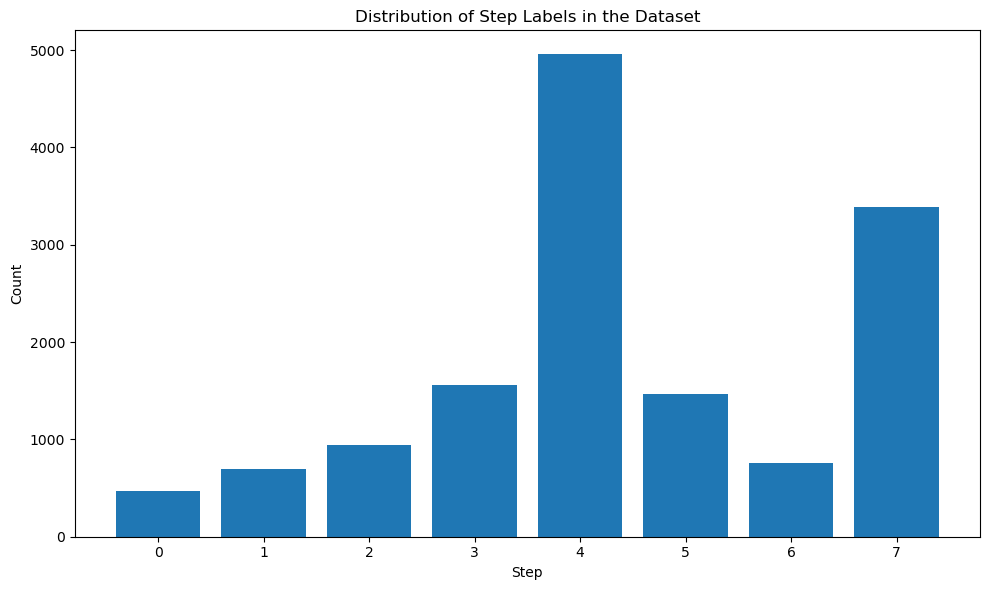

{0: 471, 1: 699, 2: 945, 3: 1560, 4: 4956, 5: 1467, 6: 762, 7: 3393}


In [147]:
val_class_counts = window_class_counts(val_datasets)
counts = {label: int(count) for label, count in enumerate(val_class_counts) if count}

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

### model

In [148]:
# Inspect one window; no DataLoader iterator is needed.
x_sample, y_sample = full_dataset[0]

input_dim = x_sample.shape[-1]
num_mistakes = 2
num_steps = max(int(d.step.max()) for d in datasets) + 1

print("Input dim:", input_dim)
print("Num steps:", num_steps)
print("X shape:", x_sample.shape)
print("Step shape:", y_sample["step"].shape)
print("Step values:", y_sample["step"].unique())
print("Progress shape:", y_sample["progress"].shape)
print("Progress values:", y_sample["progress"].unique())
print("Mistakes shape:", y_sample["mistake"].shape)
print("Task mistakes:", y_sample["mistake"].unique())

model = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_layer,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes,
).to(device)

Input dim: 89
Num steps: 8
X shape: torch.Size([160, 89])
Step shape: torch.Size([])
Step values: tensor([1])
Progress shape: torch.Size([])
Progress values: tensor([0.6785])
Mistakes shape: torch.Size([])
Task mistakes: tensor([0])


In [149]:
x_val_sample, y_val_sample = fulldataset_val[0]
print("progress value", y_val_sample["progress"].unique())
print("step value", y_val_sample["step"].unique())

progress value tensor([0.1181])
step value tensor([1])


In [ ]:

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Count task_id targets of training windows, not all raw frames.
if mode != "seq2one":
    raise ValueError("Task class weighting currently requires seq2one mode.")
step_class_counts = np.pad(train_class_counts, (0, num_steps - len(train_class_counts)))

if np.any(step_class_counts == 0):
    raise ValueError(f"No training windows for task IDs: {np.flatnonzero(step_class_counts == 0).tolist()}")

# Square-root inverse frequency: average training-sample weight is 1.
step_weights = 1.0 / step_class_counts


step_weights /= np.average(step_weights, weights=step_class_counts)
step_class_weights = torch.tensor(
    step_weights,
    dtype=torch.float32, device=device,
)
print("Task ID window counts:", step_class_counts.tolist())
print("Task ID class weights:", step_class_weights.tolist())

# Average weighted samples explicitly so single-class batches retain their weight.
if weighted_loss:
    step_ce_loss = nn.CrossEntropyLoss(weight=step_class_weights, reduction="none")
else:
    step_ce_loss = nn.CrossEntropyLoss(reduction="none")
# step_ce_loss = nn.CrossEntropyLoss()
ce_loss = nn.CrossEntropyLoss()  # Mistake classification remains unweighted.
mse_loss = nn.MSELoss()

#should adjust later
lambda_step = 1.0
lambda_progress = 1.0
lambda_mistake = 1.0


Task ID window counts: [2994, 3096, 4611, 7947, 33072, 6405, 5844, 19107]
Task ID class weights: [2.0407657623291016, 2.006866931915283, 1.6444530487060547, 1.2526144981384277, 0.6140288710594177, 1.3952739238739014, 1.460709810256958, 0.8078352212905884]


In [ ]:
# out = model(x)

# print(type(out))

# if isinstance(out, tuple):
#     print("number of outputs:", len(out))
#     for i, item in enumerate(out):
#         print(i, type(item))
#         if hasattr(item, "shape"):
#             print(item.shape)
# else:
#     print(out)

# loging + training

In [151]:

import json
import csv
from pathlib import Path
from datetime import datetime
from sklearn.metrics import f1_score


run_name = datetime.now().strftime("exp_%Y-%m-%d_%H-%M-%S")
run_dir = Path("runs_3d") / run_name
run_dir.mkdir(parents=True, exist_ok=True)

config = {
    "feature_keys": x_keys,
    "normalize": True,
    "window_size": window_size,
    "stride": stride,
    "predict_offset": predict_offset,
    "mode": mode,

    "test_notes" : test_notes,

    "weight_decay": weight_decay,
    "weighted_loss": weighted_loss,

    "model": "LSTM",
    "input_dim": input_dim,
    "hidden_dim": hidden_layer,
    "num_steps": num_steps,
    "num_mistakes": num_mistakes,
    "num_layers": num_layers,
    "dropout": dropout,

    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": lr,
    "lambda_step": lambda_step,
    "lambda_progress": lambda_progress,
    "lambda_mistake": lambda_mistake,

    "training_shuffle": train_shuffle,
    "training_sampler": "WeightedRandomSampler",
    "sampler_weighting": "inverse_window_class_frequency",
    "sampler_replacement": train_sampler.replacement,
    "sampler_num_samples": train_sampler.num_samples,
    "sampler_seed": sampler_seed,
    "train_metrics_distribution": "balanced_sampled",
    "num_workers": num_workers,
    "dataset_feature_cache": "npy_memmap",
    "dataset_cache_dir": str(dataset_cache_dir),
    "step_class_counts": step_class_counts.tolist(),
    "step_class_weights": step_class_weights.tolist() if weighted_loss else None,
    "step_loss_reduction": "weighted_sample_mean" if weighted_loss else "mean",
    "step_weighting": "sqrt_inverse_frequency" if weighted_loss else "none",

}

with open(run_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# ========================================
#TRANING LOOP    
# ========================================

metrics_path = run_dir / "metrics.csv"

with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "train_step_loss",
        "val_step_loss",
        "train_progress_loss",
        "val_progress_loss",
        "train_acc",
        "val_acc",
        "train_progress_mae",
        "val_progress_mae",
        "train_mistake_loss",
        "val_mistake_loss",
        "train_mistake_acc",
        "val_mistake_acc",
        "val_step_macro_f1",
    ])


best_val_loss = float("inf")
best_epoch = -1
best_val_step_macro_f1 = -1.0

for epoch in range(epochs):


    model.train()

    total_train_loss = 0.0
    total_train_step_loss = 0.0
    total_train_mistake_loss = 0.0
    total_train_mistake_correct = 0
    total_train_progress_loss = 0.0
    total_train_progress_mae = 0.0

    total_correct = 0
    total_samples = 0

#region: no constraint    
    # =========================
    # train: no constraint
    # =========================
    for x, y in loader:
        x = x.to(device, non_blocking=(device.type == "cuda"))
        y_step = y["step"].to(device, non_blocking=(device.type == "cuda"))
        y_progress = y["progress"].to(device, non_blocking=(device.type == "cuda"))
        y_mistake = y["mistake"].to(device, non_blocking=(device.type == "cuda"))

        optimizer.zero_grad()

        step_pred, progress_pred, mistake_pred = model(x)

        loss_step = step_ce_loss(step_pred, y_step).mean()
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
        # step only ablation test
        # loss = loss_step
        loss.backward()
        optimizer.step()

        n_batch = x.size(0)

        total_train_loss += loss.item() * n_batch
        total_train_step_loss += loss_step.item() * n_batch
        total_train_progress_loss += loss_progress.item() * n_batch
        total_train_mistake_loss += loss_mistake.item() * n_batch
        total_train_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
        total_train_progress_mae += progress_mae.item() * n_batch

        preds = torch.argmax(step_pred, dim=1)
        total_correct += (preds == y_step).sum().item()
        total_samples += n_batch
#endregion: no constraint


#region: constraint
    # =========================
    # train: constraint
    # =========================

#endregion:

    train_loss = total_train_loss / total_samples
    train_step_loss = total_train_step_loss / total_samples
    train_progress_loss = total_train_progress_loss / total_samples
    train_progress_mae = total_train_progress_mae / total_samples
    train_acc = total_correct / total_samples
    train_mistake_loss = total_train_mistake_loss / total_samples
    train_mistake_acc = total_train_mistake_correct / total_samples


    # =========================
    # validation
    # =========================
    model.eval()

    total_val_loss = 0.0
    total_val_step_loss = 0.0
    total_val_mistake_loss = 0.0
    total_val_mistake_correct = 0
    total_val_progress_loss = 0.0
    total_val_progress_mae = 0.0

    total_val_correct = 0
    total_val_samples = 0
    val_true_steps = []
    val_pred_steps = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=(device.type == "cuda"))
            y_step = y["step"].to(device, non_blocking=(device.type == "cuda"))
            y_progress = y["progress"].to(device, non_blocking=(device.type == "cuda"))
            y_mistake = y["mistake"].to(device, non_blocking=(device.type == "cuda"))

            step_pred, progress_pred, mistake_pred = model(x)

            loss_step = step_ce_loss(step_pred, y_step).mean()
            loss_progress = mse_loss(progress_pred, y_progress)
            loss_mistake = ce_loss(mistake_pred, y_mistake)
            loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
            # loss = loss_step
            
            n_batch = x.size(0)

            total_val_loss += loss.item() * n_batch
            total_val_step_loss += loss_step.item() * n_batch
            total_val_progress_loss += loss_progress.item() * n_batch
            total_val_mistake_loss += loss_mistake.item() * n_batch
            total_val_mistake_correct += (mistake_pred.argmax(dim=1) == y_mistake).sum().item()

            progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
            total_val_progress_mae += progress_mae.item() * n_batch

            preds = torch.argmax(step_pred, dim=1)
            total_val_correct += (preds == y_step).sum().item()
            total_val_samples += n_batch
            val_true_steps.extend(y_step.cpu().tolist())
            val_pred_steps.extend(preds.cpu().tolist())

    val_loss = total_val_loss / total_val_samples
    val_step_loss = total_val_step_loss / total_val_samples
    val_progress_loss = total_val_progress_loss / total_val_samples
    val_progress_mae = total_val_progress_mae / total_val_samples
    val_acc = total_val_correct / total_val_samples
    val_mistake_loss = total_val_mistake_loss / total_val_samples
    val_mistake_acc = total_val_mistake_correct / total_val_samples
    # Compute once over all validation windows, including every configured class.
    val_step_macro_f1 = f1_score(
        val_true_steps, val_pred_steps, labels=range(num_steps),
        average="macro", zero_division=0,
    )


    # =========================
    # print
    # =========================
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Step Loss: {train_step_loss:.4f} "
        f"| Progress Loss: {train_progress_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Train Progress MAE: {train_progress_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Step Loss: {val_step_loss:.4f} "
        f"| Val Progress Loss: {val_progress_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Step Macro F1: {val_step_macro_f1:.4f} "
        f"| Val Progress MAE: {val_progress_mae:.4f} "
        f"| Train Mistake Loss: {train_mistake_loss:.4f} "
        f"| Train Mistake Acc: {train_mistake_acc:.4f} "
        f"| Val Mistake Loss: {val_mistake_loss:.4f} "
        f"| Val Mistake Acc: {val_mistake_acc:.4f}"
    )


    # =========================
    # write metrics
    # =========================
    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            val_loss,
            train_step_loss,
            val_step_loss,
            train_progress_loss,
            val_progress_loss,
            train_acc,
            val_acc,
            train_progress_mae,
            val_progress_mae,
            train_mistake_loss,
            val_mistake_loss,
            train_mistake_acc,
            val_mistake_acc,
            val_step_macro_f1,
        ])


    # =========================
    # save best model
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(model.state_dict(), run_dir / "best_model.pth")

        summary = {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "best_val_step_loss": val_step_loss,
            "best_val_progress_loss": val_progress_loss,
            "best_val_acc": val_acc,
            "val_step_macro_f1": val_step_macro_f1,
            "best_val_mistake_loss": val_mistake_loss,
            "best_val_mistake_acc": val_mistake_acc,
            "best_val_progress_mae": val_progress_mae,
            "model_path": str(run_dir / "best_model.pth"),
        }

        with open(run_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=4)
    # Independent selection: the F1 checkpoint may come from another epoch.
    if val_step_macro_f1 > best_val_step_macro_f1:
        best_val_step_macro_f1 = val_step_macro_f1
        f1_model_path = run_dir / "best_step_macro_f1.pth"
        torch.save(model.state_dict(), f1_model_path)
        f1_summary = {
            "best_epoch": epoch + 1,
            "best_val_step_macro_f1": best_val_step_macro_f1,
            "val_loss": val_loss,
            "val_step_loss": val_step_loss,
            "val_acc": val_acc,
            "model_path": str(f1_model_path),
        }
        with open(run_dir / "summary_step_macro_f1.json", "w") as f:
            json.dump(f1_summary, f, indent=4)


Epoch 1/60 | Train Loss: 2.5194 | Step Loss: 2.0396 | Progress Loss: 0.1124 | Train Acc: 0.3492 | Train Progress MAE: 0.2674 | Val Loss: 2.3117 | Val Step Loss: 2.0434 | Val Progress Loss: 0.1068 | Val Acc: 0.2934 | Val Step Macro F1: 0.2180 | Val Progress MAE: 0.2669 | Train Mistake Loss: 0.3674 | Train Mistake Acc: 0.8859 | Val Mistake Loss: 0.1614 | Val Mistake Acc: 0.9703
Epoch 2/60 | Train Loss: 2.0915 | Step Loss: 1.6749 | Progress Loss: 0.1033 | Train Acc: 0.4651 | Train Progress MAE: 0.2548 | Val Loss: 2.3802 | Val Step Loss: 2.1178 | Val Progress Loss: 0.1085 | Val Acc: 0.3069 | Val Step Macro F1: 0.2305 | Val Progress MAE: 0.2661 | Train Mistake Loss: 0.3133 | Train Mistake Acc: 0.8909 | Val Mistake Loss: 0.1538 | Val Mistake Acc: 0.9703
Epoch 3/60 | Train Loss: 1.9430 | Step Loss: 1.5334 | Progress Loss: 0.0990 | Train Acc: 0.5102 | Train Progress MAE: 0.2511 | Val Loss: 2.3370 | Val Step Loss: 2.0846 | Val Progress Loss: 0.1078 | Val Acc: 0.3458 | Val Step Macro F1: 0.2593 

# ====================================================================================

# Evaluate model performance with test dataset

### load the best model

In [152]:
# Keep the run produced by the training cell above.
# To evaluate an older experiment, explicitly set run_dir here.
print("Evaluating run:", run_dir)


Evaluating run: runs_3d\exp_2026-09-24_17-02-55


In [153]:
best_model_path_dir = run_dir
best_model_path = best_model_path_dir / "best_step_macro_f1.pth"


## plot loss curves (train VS val)

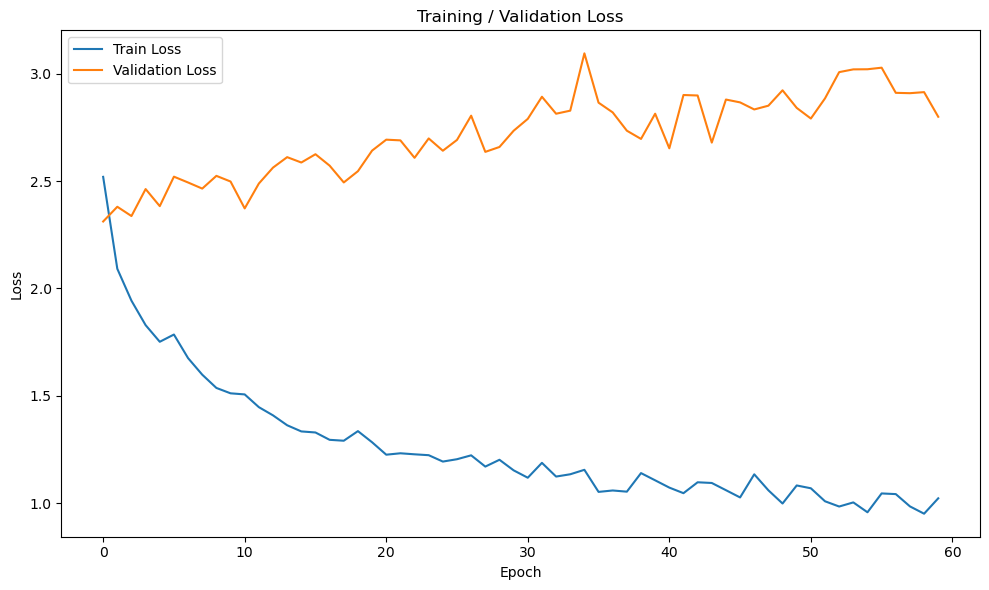

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_loss"], label="Train Loss")
ax.plot(metrics_df["val_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)



## plot loss curves (step train VS step val)

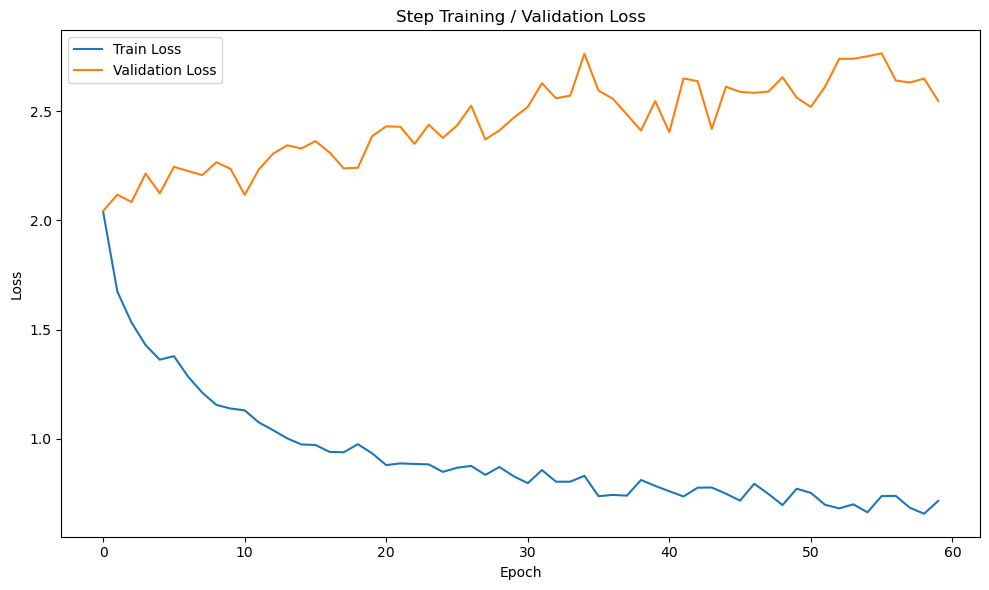

In [155]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_step_loss"], label="Train Loss")
ax.plot(metrics_df["val_step_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Step Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Step_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (Mistake train VS step val)

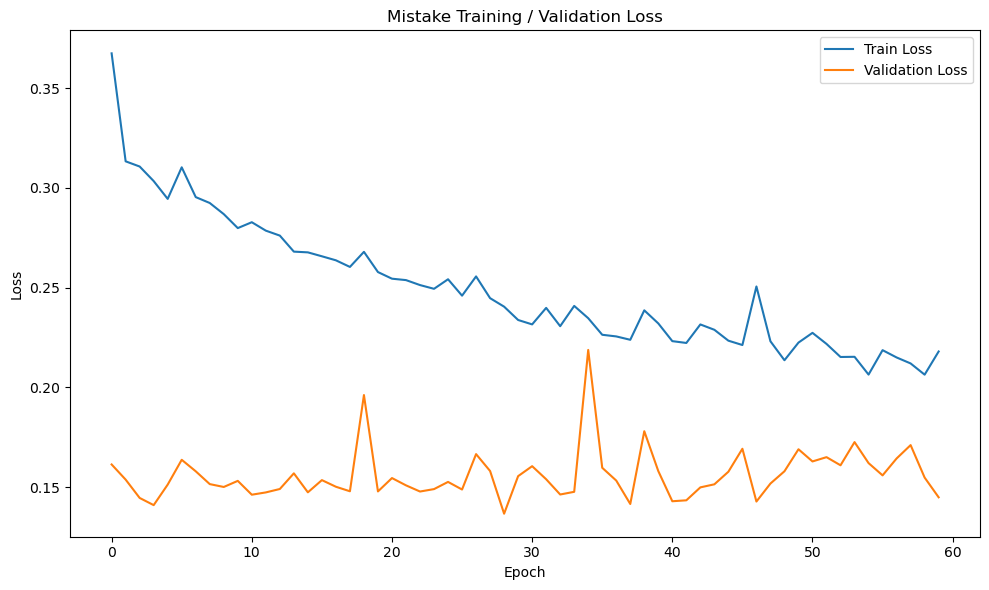

In [156]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_mistake_loss"], label="Train Loss")
ax.plot(metrics_df["val_mistake_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Mistake Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Mistake_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (progress train VS step val)

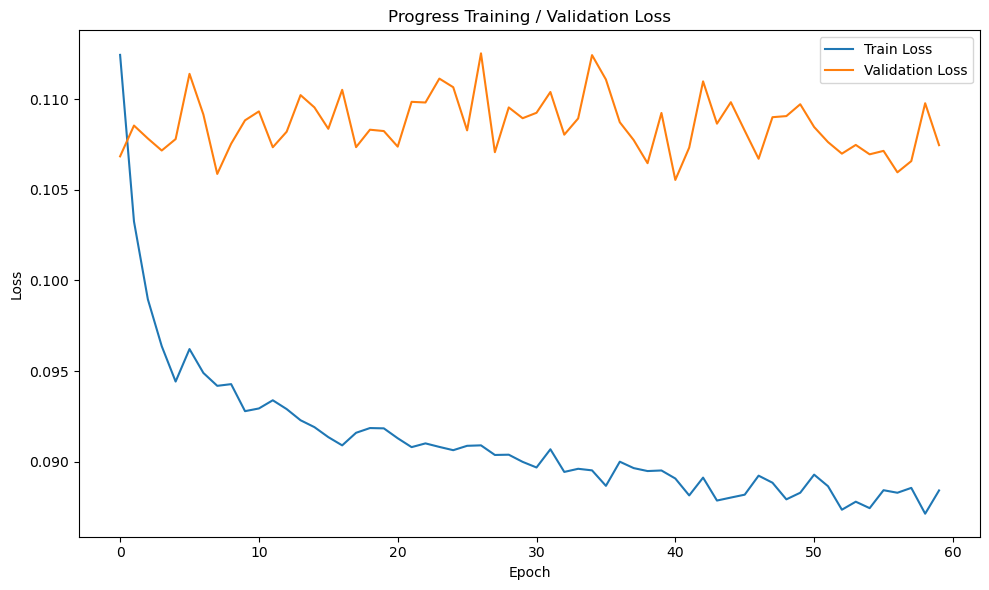

In [157]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_progress_loss"], label="Train Loss")
ax.plot(metrics_df["val_progress_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Progress Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Progress_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

In [163]:
import json
best_model_config = best_model_path_dir / "config.json"
best_model_config = json.loads(best_model_config.read_text())
input_dim = best_model_config["input_dim"]
hidden_dim = best_model_config["hidden_dim"]
num_steps = best_model_config["num_steps"]
num_layers = best_model_config.get("num_layers", 1)
dropout = best_model_config.get("dropout", 0.0)
num_mistakes = best_model_config["num_mistakes"]
lambda_mistake = best_model_config["lambda_mistake"]

best_weight_loss = best_model_config.get("weighted_loss", False)

# Restore the training weights; older runs used ordinary cross entropy.
saved_step_weights = best_model_config.get("step_class_weights")
if best_weight_loss:
    step_ce_loss = nn.CrossEntropyLoss(
        weight=(torch.tensor(saved_step_weights, dtype=torch.float32, device=device)
                if saved_step_weights is not None else None),
        reduction="none",
    )
else:
    step_ce_loss = nn.CrossEntropyLoss(reduction="none")
# step_ce_loss = nn.CrossEntropyLoss()


In [164]:
model_eval = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_steps=num_steps,
    dropout=dropout,
    num_layers=num_layers,
    num_mistakes=num_mistakes
).to(device)

model_eval.load_state_dict(torch.load(best_model_path, map_location=device))

model_eval.eval()

AssistLSTM(
  (lstm): LSTM(89, 64, batch_first=True)
  (shared): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (step_head): Linear(in_features=64, out_features=8, bias=True)
  (progress_head): Linear(in_features=64, out_features=1, bias=True)
  (mistake_head): Linear(in_features=64, out_features=2, bias=True)
)

### Train confusion matrix (best validation checkpoint)

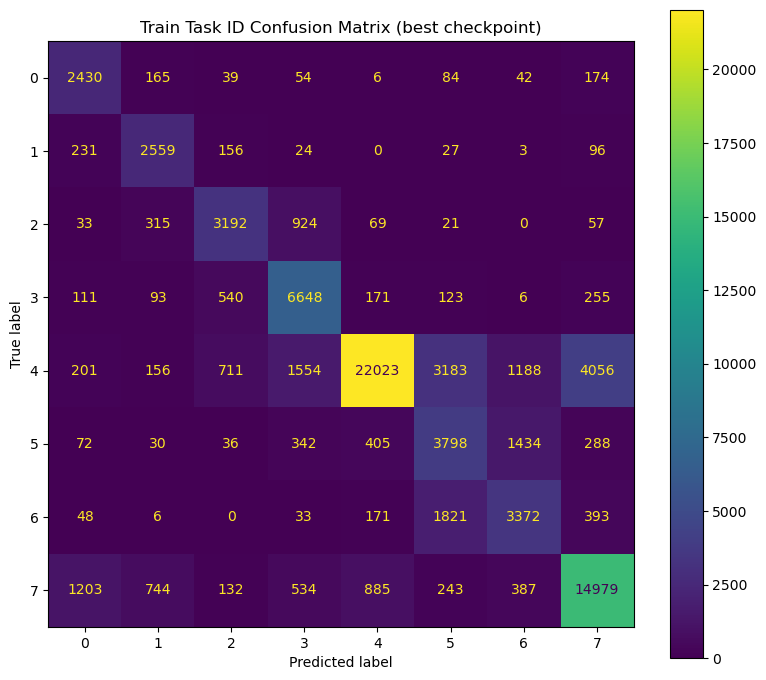

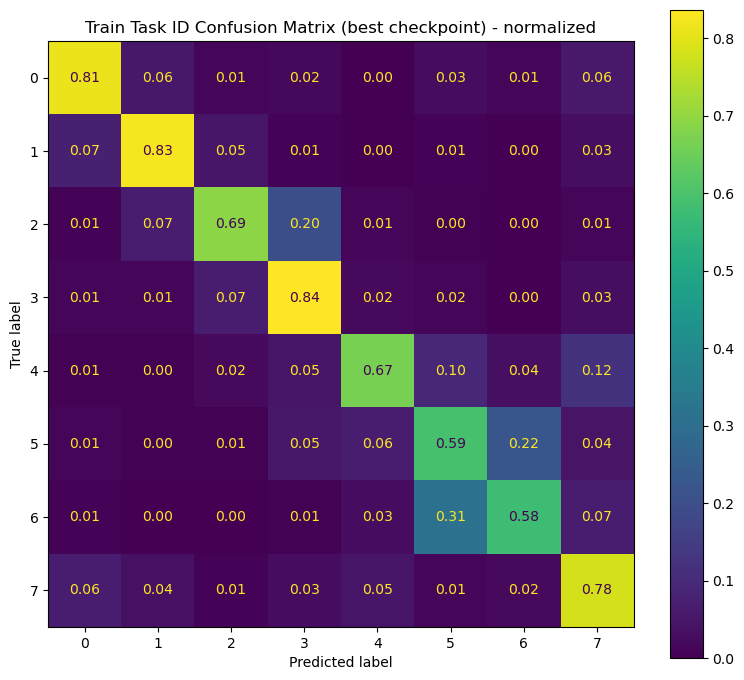

In [169]:
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluate all training windows with the best validation checkpoint.
train_true_steps = []
train_pred_steps = []
model_eval.eval()
with torch.no_grad():
    for x, y in train_eval_loader:
        train_step_logits, _, _ = model_eval(x.to(device, non_blocking=(device.type == "cuda")))
        train_true_steps.extend(y["step"].cpu().tolist())
        train_pred_steps.extend(train_step_logits.argmax(dim=1).cpu().tolist())

for normalize, suffix, values_format in [(None, "", "d"), ("true", "_norm", ".2f")]:
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        train_true_steps,
        train_pred_steps,
        labels=np.arange(num_steps),
        normalize=normalize,
        values_format=values_format,
        cmap=None,
        ax=ax,
    )
    ax.set_title("Train Task ID Confusion Matrix (best checkpoint)"
                 + (" - normalized" if normalize else ""))
    fig.tight_layout()
    fig.savefig(
        best_model_path_dir / f"train_step_confusion_matrix{suffix}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


## load & norm test data

In [170]:
# Training-set evaluation is complete; release its mappings before loading test data.
release_notebook_data(
    "loader", "train_eval_loader", "train_sampler", "full_dataset", "datasets", "dataset", "x_sample", "y_sample",
    "val_loader", "fulldataset_val", "val_datasets", "val_dataset", "x_val_sample", "y_val_sample",
    "train_targets", "val_targets", "train_true_steps", "train_pred_steps", "x", "y",
)

test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\raw"
test_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".pt")]

npz_test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\norm"

In [171]:
# Reuse cached files; use a new directory if normalization statistics change.
Path(npz_test_dir).mkdir(parents=True, exist_ok=True)
builder = NormDatasetBuilder(norm_stats)
for test_path in test_paths:
    out_path = Path(npz_test_dir) / (Path(test_path).stem + "_norm.npz")
    if not out_path.exists():
        builder.build_dataset(test_path, str(out_path))

npz_test_paths = [os.path.join(npz_test_dir, f) for f in os.listdir(npz_test_dir) if f.endswith(".npz")]
print(len(npz_test_paths))


27


## test dataset

In [172]:
release_notebook_data("test_loader", "fulldataset_test", "test_datasets", "test_dataset",
                      "test_targets", "all_rows", "pred_df")
test_datasets = []
for npz_test_path in npz_test_paths:
    print(f"Loading test dataset from {npz_test_path}...")
    test_dataset = AssistSequenceDataset(npz_path=npz_test_path,
                                         window_size=window_size,
                                         stride=stride,
                                         predict_offset=predict_offset,
                                         mode=mode,
                                         feature_keys=x_keys,
                                         cache_dir=dataset_cache_dir)
    test_datasets.append(test_dataset)    

fulldataset_test = ConcatDataset(test_datasets)
test_loader = DataLoader(fulldataset_test, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\norm\features__cam-07_uid-02_take-03_aug-01_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\norm\features__cam-07_uid-02_take-03_aug-03_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\norm\features__cam-07_uid-02_take-03_aug-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset\skeleton_3d\ceiling_panel_installation_04\aug_test\norm\features__cam-07_uid-02_take-02_aug-03_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\datas

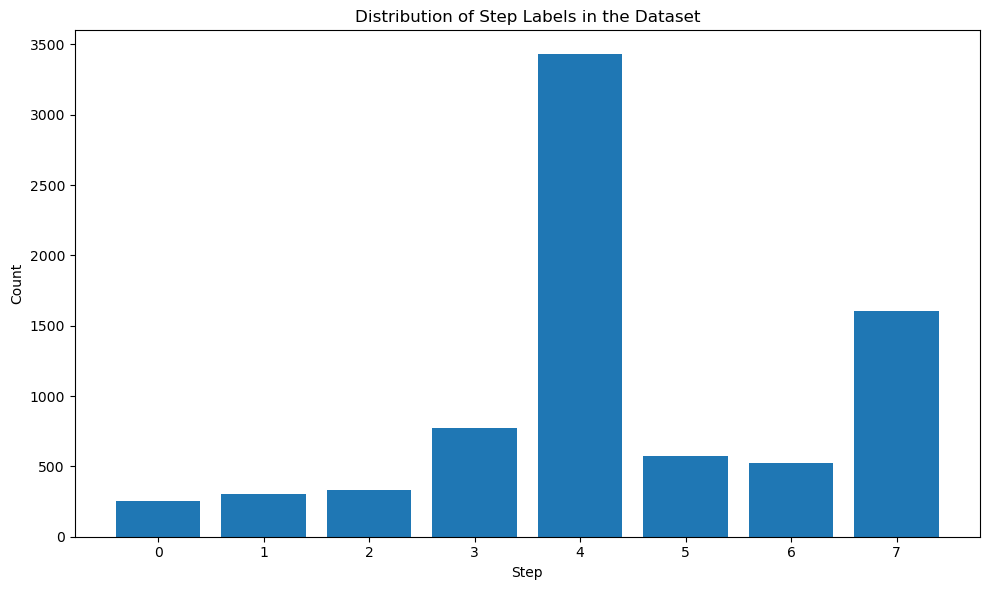

{0: 252, 1: 306, 2: 333, 3: 774, 4: 3429, 5: 576, 6: 522, 7: 1608}


In [173]:
test_class_counts = window_class_counts(test_datasets)
counts = {label: int(count) for label, count in enumerate(test_class_counts) if count}

#plot the counts
plt.figure(figsize=(10, 6))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Step")
plt.ylabel("Count")
plt.title("Distribution of Step Labels in the Dataset")

plt.tight_layout()
plt.show()

print(counts)

In [174]:
import pandas as pd
import json

total_loss = 0.0
total_step_loss = 0.0
total_mistake_loss = 0.0
total_mistake_correct = 0
total_progress_loss = 0.0
total_progress_mae = 0.0

total_correct = 0
total_samples = 0

all_rows = []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        x = x.to(device, non_blocking=(device.type == "cuda"))
        y_step = y["step"].to(device, non_blocking=(device.type == "cuda"))
        y_progress = y["progress"].to(device, non_blocking=(device.type == "cuda"))
        y_mistake = y["mistake"].to(device, non_blocking=(device.type == "cuda"))

        step_logits, progress_pred, mistake_pred = model_eval(x)

        loss_step = step_ce_loss(step_logits, y_step).mean()
        loss_progress = mse_loss(progress_pred, y_progress)
        loss_mistake = ce_loss(mistake_pred, y_mistake)
        loss = lambda_step * loss_step + lambda_progress * loss_progress + lambda_mistake * loss_mistake
        # loss = loss_step

        preds_mistake = mistake_pred.argmax(dim=1)
        preds_step = torch.argmax(step_logits, dim=1)
        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))

        n_batch = x.size(0)

        total_loss += loss.item() * n_batch
        total_step_loss += loss_step.item() * n_batch
        total_progress_loss += loss_progress.item() * n_batch
        total_mistake_loss += loss_mistake.item() * n_batch
        total_mistake_correct += (preds_mistake == y_mistake).sum().item()
        total_progress_mae += progress_mae.item() * n_batch

        total_correct += (preds_step == y_step).sum().item()
        total_samples += n_batch

        # save predictions
        for i in range(n_batch):
            all_rows.append({
                "batch_idx": batch_idx,
                "sample_idx_in_batch": i,
                "true_mistake": int(y_mistake[i].cpu().item()),
                "pred_mistake": int(preds_mistake[i].cpu().item()),
                "true_step": int(y_step[i].cpu().item()),
                "pred_step": int(preds_step[i].cpu().item()),
                "true_progress": float(y_progress[i].cpu().item()),
                "pred_progress": float(progress_pred[i].cpu().item()),
                "progress_abs_error": float(
                    torch.abs(progress_pred[i] - y_progress[i]).cpu().item()
                ),
            })

test_loss = total_loss / total_samples
test_step_loss = total_step_loss / total_samples
test_progress_loss = total_progress_loss / total_samples
test_progress_mae = total_progress_mae / total_samples
test_acc = total_correct / total_samples
test_mistake_loss = total_mistake_loss / total_samples
test_mistake_acc = total_mistake_correct / total_samples

results = {
    "test_loss": test_loss,
    "test_step_loss": test_step_loss,
    "test_progress_loss": test_progress_loss,
    "test_acc": test_acc,
    "test_mistake_loss": test_mistake_loss,
    "test_mistake_acc": test_mistake_acc,
    "test_progress_mae": test_progress_mae,
    "test_progress_mae_percent": test_progress_mae * 100,
}

pred_df = pd.DataFrame(all_rows)

In [175]:
pred_df.to_csv(best_model_path_dir / "test_predictions.csv", index=False)

with open(best_model_path_dir / "test_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved test predictions and results.")

Saved test predictions and results.


### Step prediction

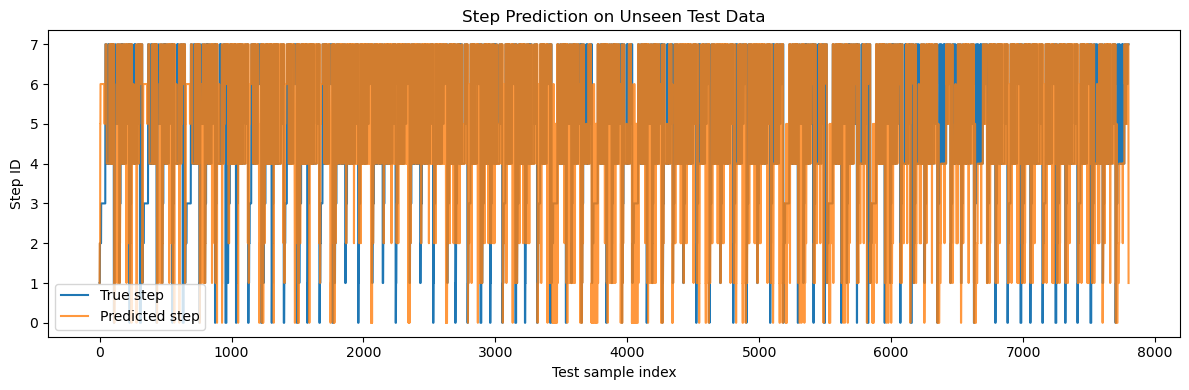

In [176]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pred_df["true_step"].values, label="True step")
ax.plot(pred_df["pred_step"].values, label="Predicted step", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Step ID")
ax.set_title("Step Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "step_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### Progress prediction & error

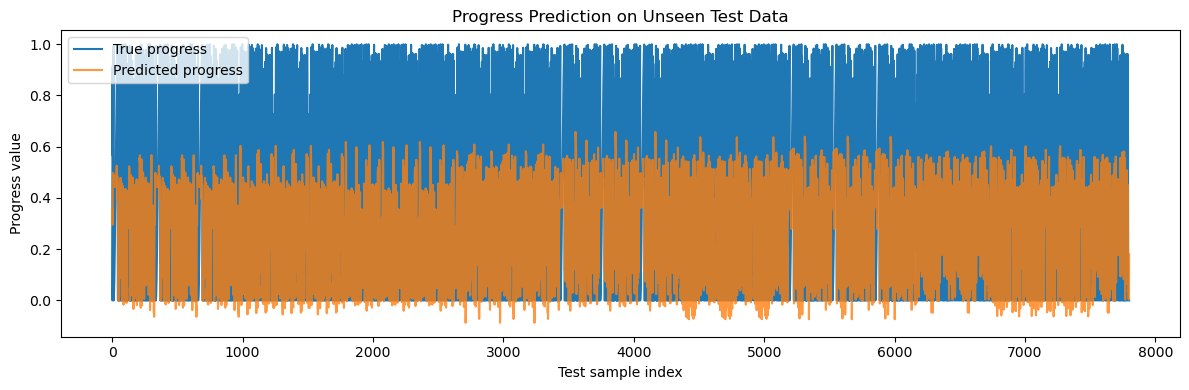

In [177]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["true_progress"].values, label="True progress")
ax.plot(pred_df["pred_progress"].values, label="Predicted progress", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Progress value")

ax.set_title("Progress Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()  
plt.close(fig)

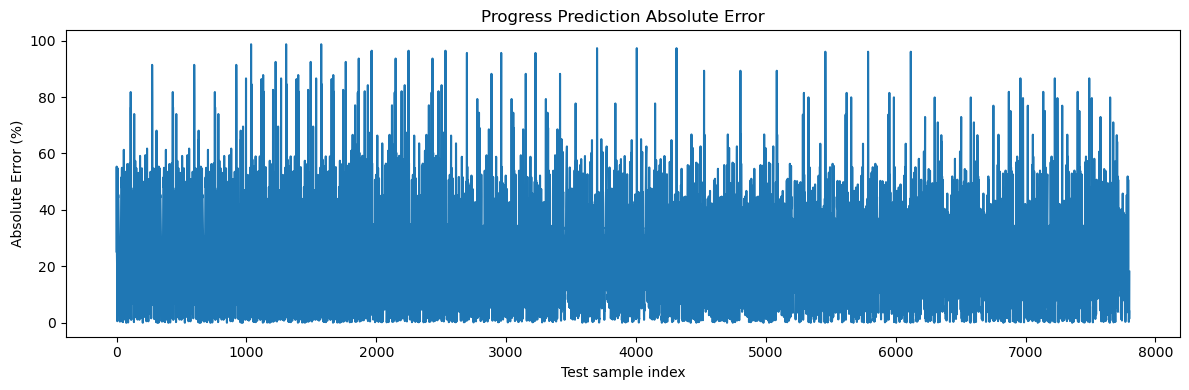

In [178]:
fig, ax  = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["progress_abs_error"].values * 100, label="Absolute Error")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Absolute Error (%)") 

ax.set_title("Progress Prediction Absolute Error")
fig.tight_layout()  
fig.savefig(best_model_path_dir / "progress_prediction_abs_error_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### step confusion

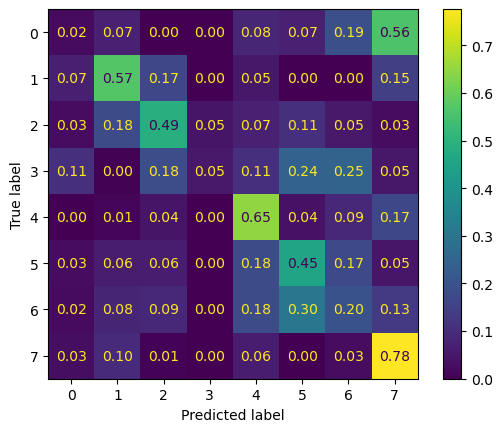

In [179]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    pred_df["true_step"],
    pred_df["pred_step"],
    normalize="true",
    values_format=".2f"
    )
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix_norm.png",
    dpi=200,
    bbox_inches="tight"
)

# plt.show()
plt.close(fig)

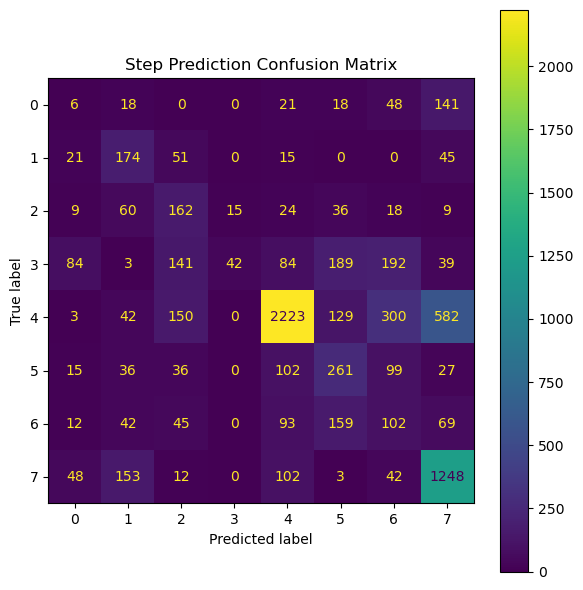

In [180]:
cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    cm
    )
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

0: "Pull Cables"
1: "Lift"
2: "Align
3: "Screw
4: "Connect Cables"
5: "Clamp Coupling"
6: "Place

### classification report

In [181]:
from sklearn.metrics import classification_report

print(
    classification_report(
        pred_df["true_step"],
        pred_df["pred_step"],
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.0303    0.0238    0.0267       252
           1     0.3295    0.5686    0.4173       306
           2     0.2714    0.4865    0.3484       333
           3     0.7368    0.0543    0.1011       774
           4     0.8345    0.6483    0.7297      3429
           5     0.3283    0.4531    0.3807       576
           6     0.1273    0.1954    0.1542       522
           7     0.5778    0.7761    0.6624      1608

    accuracy                         0.5408      7800
   macro avg     0.4045    0.4008    0.3526      7800
weighted avg     0.6173    0.5408    0.5379      7800

